# Supplementary File S2 — Lesson Plan 1: Data Splitting and Class Imbalance

**Estimated time:** 2 hours (90 min lab + 30 min debrief)
**Prerequisites:** Python basics; familiarity with pandas and matplotlib; conceptual
understanding of training/test splits.
**Materials needed:** `class_metadata.csv` (per-class image counts) and pre-trained model
output files, both produced by Supplementary File S1. No GPU is required for this notebook.

## Learning Objectives
By the end of this lesson you will be able to:
- Implement stratified splits and explain why stratification matters for imbalanced datasets.
- Compute and compare per-class distributions.
- Interpret per-class recall versus overall accuracy on an imbalanced dataset.


---
## Step 1 (15 min): Predict Before You Look

Before running any code, look through a small gallery of dish categories from the Indian
Food Image Dataset.

**Discussion — write your answers before continuing:**
1. Which 3 categories do you predict will be *easiest* for a model to classify correctly? Why?
2. Which 3 categories do you predict will be *hardest*? Why?
3. What visual features (color, shape, texture, plating) are you basing your predictions on?

*(Record your predictions in the cell below — you'll revisit them at the end of Lesson 3.)*


In [1]:
# Your predictions (edit this cell):
easiest_predictions = ["", "", ""]
hardest_predictions = ["", "", ""]
reasoning = """
Write 2-3 sentences explaining your reasoning here.
"""
print("Predictions recorded.")


Predictions recorded.


---
## Step 2 (30 min): Class Frequency Analysis

Load the class metadata produced by the S1 training notebook and examine how balanced
(or imbalanced) the dataset is.


In [3]:
# --- Mount Google Drive and set paths  ---
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.ismount('/content/drive'), 'Drive not mounted — re-run this cell.'
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False  # running locally; adjust the paths below if so

DRIVE_PROJECT   = '/content/drive/MyDrive/CEP_Food_Dataset'
OUTPUTS         = f'{DRIVE_PROJECT}/outputs'
METADATA_PATH   = f'{OUTPUTS}/class_metadata.csv'
PREDICTIONS_PATH= f'{OUTPUTS}/test_predictions.csv'

assert os.path.exists(METADATA_PATH), (
    f'Not found: {METADATA_PATH}\n'
    'Run the S1 training notebook to completion first — it writes this file to Drive.')
print('Found metadata ->', METADATA_PATH)

Mounted at /content/drive
Found metadata -> /content/drive/MyDrive/CEP_Food_Dataset/outputs/class_metadata.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(METADATA_PATH)
print(f"Total classes: {len(df)}")
print(f"Total images: {df['images'].sum():,}")
df.sort_values('images', ascending=False).head(10)


Total classes: 100
Total images: 4,577


,class,images,size_mb
45,Kothimbir_Vadi,83,196.103896
56,Methi_dry,82,586.123851
53,Matar_Paneer,71,574.613774
29,Dosa,70,523.281797
47,Malai_Peda,69,131.636600
39,Jalebi,68,353.725290
54,Mathura_Peda,68,133.638292
61,Motichoor_Laddu,68,143.119911
71,Poha,67,280.541675
81,Rava_Sheera,65,229.644723


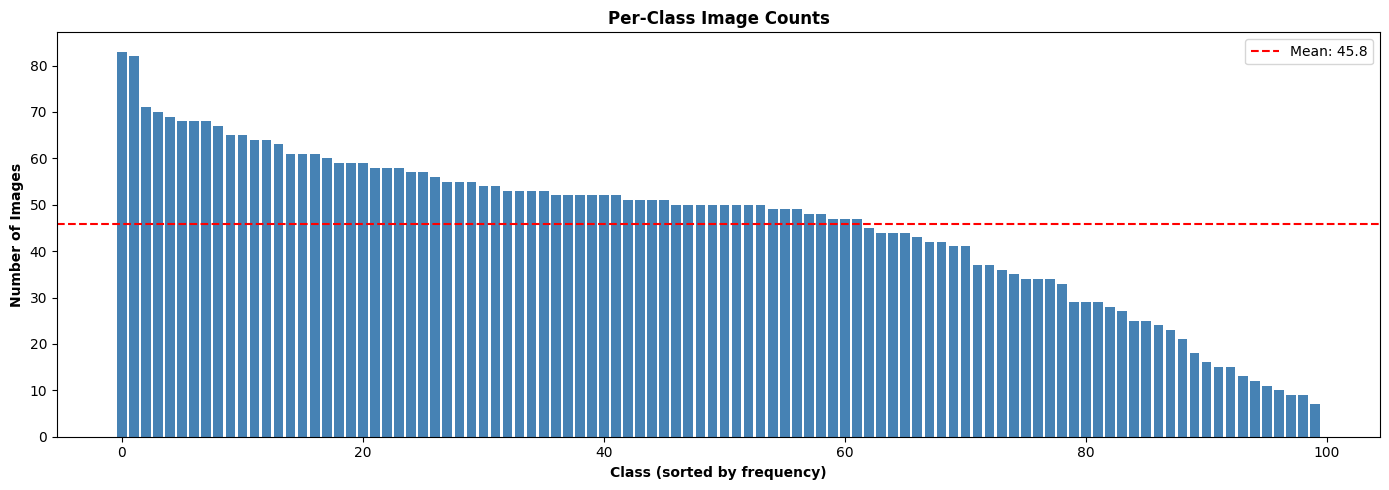

In [5]:
# Bar chart of class frequencies
fig, ax = plt.subplots(figsize=(14, 5))
df_sorted = df.sort_values('images', ascending=False)
ax.bar(range(len(df_sorted)), df_sorted['images'], color='steelblue')
ax.set_xlabel('Class (sorted by frequency)', fontweight='bold')
ax.set_ylabel('Number of Images', fontweight='bold')
ax.set_title('Per-Class Image Counts', fontweight='bold')
ax.axhline(df['images'].mean(), color='red', linestyle='--', label=f"Mean: {df['images'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Identify the 5 most and 5 least frequent classes
top5 = df.sort_values('images', ascending=False).head(5)
bottom5 = df.sort_values('images', ascending=True).head(5)

print("5 MOST frequent classes:")
print(top5[['class', 'images']].to_string(index=False))
print("\n5 LEAST frequent classes:")
print(bottom5[['class', 'images']].to_string(index=False))


5 MOST frequent classes:
         class  images
Kothimbir_Vadi      83
     Methi_dry      82
  Matar_Paneer      71
          Dosa      70
    Malai_Peda      69

5 LEAST frequent classes:
       class  images
Spicy_vatana       7
  Egg_bhurji       9
  Rava_barfi       9
   Pani_Puri      10
 Masala_oats      11


**Discussion:** What would happen to per-class recall if the train/test split were done
completely randomly (not stratified) on a dataset this imbalanced? Consider a low-frequency
class with only 20-25 images — how many might end up in the test set purely by chance under
random sampling, versus under stratified sampling?


---
## Step 3 (25 min): Implement Stratified Splitting

Now implement stratified splitting yourself and verify that class proportions are preserved.


In [7]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from scipy.stats import chisquare

# Simulate a labels array matching the class distribution in df
# (in the real pipeline this comes from the actual file paths + labels — see S1)
labels = []
for idx, row in df.iterrows():
    labels.extend([row['class']] * int(row['images']))
labels = np.array(labels)

print(f"Total samples: {len(labels)}")


Total samples: 4577


In [8]:
# Stratified split: 70% train, 15% val, 15% test
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(sss.split(np.zeros(len(labels)), labels))

temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx_rel, test_idx_rel = next(sss2.split(np.zeros(len(temp_idx)), temp_labels))

train_labels = labels[train_idx]
val_labels = temp_labels[val_idx_rel]
test_labels = temp_labels[test_idx_rel]

print(f"Train: {len(train_labels)} | Val: {len(val_labels)} | Test: {len(test_labels)}")


Train: 3203 | Val: 687 | Test: 687


In [9]:
# Verify stratification preserved class proportions using a chi-square test
train_counts = pd.Series(train_labels).value_counts(normalize=True).sort_index()
test_counts = pd.Series(test_labels).value_counts(normalize=True).sort_index()

# Align indices (some rare classes might not appear if the class had very few images)
common_classes = train_counts.index.intersection(test_counts.index)
observed = test_counts[common_classes].values * len(test_labels)
expected = train_counts[common_classes].values * len(test_labels)
expected = expected * (observed.sum() / expected.sum())  # normalize to same total

chi2_stat, p_value = chisquare(observed, expected)
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print("\nInterpretation: a high p-value (e.g. > 0.05) suggests the train and test class")
print("distributions are NOT significantly different -- i.e. stratification worked.")


Chi-square statistic: 4.051
p-value: 1.0000

Interpretation: a high p-value (e.g. > 0.05) suggests the train and test class
distributions are NOT significantly different -- i.e. stratification worked.


**Compare to a non-stratified (random) split:** repeat the split using plain
`train_test_split(..., stratify=None)` and recompute the chi-square statistic. Is it larger
or smaller? What does that tell you about the effect of stratification?


In [10]:
X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    np.arange(len(labels)), labels, test_size=0.30, random_state=42, stratify=None
)
# Repeat the chi-square comparison for the random split and compare to the stratified result above.


---
## Step 4 (20 min): Overall Accuracy vs. Per-Class Recall

Compare overall accuracy to per-class recall using your trained model's predictions.

> **Note:** the original lesson template compared *three* provided checkpoints (Model A/B/C).
> Your S1 pipeline produces a single prediction file, `test_predictions.csv`. The cell below
> uses that file, and still picks up the three-model files automatically if your instructor
> places them in the outputs folder.

In [12]:
from sklearn.metrics import accuracy_score, recall_score

def analyze(preds, label):
    overall_acc = accuracy_score(preds['true_class'], preds['pred_class'])
    per_class_recall = recall_score(preds['true_class'], preds['pred_class'],
                                    average=None, zero_division=0)
    print(f"{label}: overall accuracy = {overall_acc*100:.2f}%, "
          f"min per-class recall = {per_class_recall.min()*100:.2f}%, "
          f"classes with recall < 20%: {(per_class_recall < 0.20).sum()}")
    return per_class_recall

# Optional three-model files (used only if present)
model_files = {
    "model_a_predictions.csv": "Model A",
    "model_b_predictions.csv": "Model B",
    "model_c_predictions.csv": "Model C",
}

found_any = False
for fname, label in model_files.items():
    path = os.path.join(OUTPUTS, fname)
    if os.path.exists(path):
        analyze(pd.read_csv(path), label); found_any = True

if not found_any:
    if os.path.exists(PREDICTIONS_PATH):
        print("Three-model files not found — using your trained model's test_predictions.csv:\n")
        recall = analyze(pd.read_csv(PREDICTIONS_PATH), "Your trained model")
    else:
        print("No prediction files found. Run the S1 training notebook to completion first.")
        print(f"(expected: {PREDICTIONS_PATH})")


Three-model files not found — using your trained model's test_predictions.csv:

Your trained model: overall accuracy = 90.68%, min per-class recall = 33.33%, classes with recall < 20%: 0


In [13]:
# Zoom in: which specific classes have the worst recall in your model?
if os.path.exists(PREDICTIONS_PATH):
    preds = pd.read_csv(PREDICTIONS_PATH)
    classes = sorted(preds['true_class'].unique())
    rec = recall_score(preds['true_class'], preds['pred_class'],
                       labels=classes, average=None, zero_division=0)
    worst = pd.DataFrame({'class': classes, 'recall': rec}).sort_values('recall').head(10)
    print('10 worst-recall classes:')
    print(worst.to_string(index=False))

10 worst-recall classes:
         class   recall
  Veg_sandwich 0.333333
    Dahi_Kadhi 0.500000
  Manchow_soup 0.500000
Chilli_chicken 0.500000
     Misal_pav 0.500000
      Fish_fry 0.600000
   Mango_barfi 0.625000
   Chicken_fry 0.666667
 Sabudana_Usal 0.666667
          Poha 0.700000


**Observe:** it's possible for a model to have high overall accuracy while having
near-zero recall on some low-frequency classes. Why does overall accuracy hide this?

---
## Debrief (30 min)

Discuss as a class:
- When is overall accuracy misleading?
- What metric would you report to a hospital deploying a disease classification model, and why?

---
## Assessment

**Short written response (submit separately):** Describe one real-world classification
problem where a class-imbalanced dataset could cause harm if evaluated using accuracy alone.
Propose and justify an alternative metric.

*(Rubric for this assessment: see Supplementary File S7.)*
